In [9]:
!pip install nltk
!pip install wordcloud

## a) Create an NLTK-corpus

In [3]:
import nltk
from nltk.corpus import PlaintextCorpusReader
from nltk.tokenize import RegexpTokenizer
from collections import Counter
import os

In [ ]:
# 1. Setting the path
file_dir = r"C:\Users\aabab\ATP_HW1"
file_name = "all_diseases_text.txt"

In [12]:
# 2. Setting pattern
sent_tokenizer = RegexpTokenizer(r'[^.!?]+')

# 3. Corpus with PlaintextCorpusReader
corpus = PlaintextCorpusReader(file_dir, file_name, sent_tokenizer=sent_tokenizer)

# 4. Counting word freq
all_words = corpus.words()
word_freq = Counter(all_words)

# 5. output
top_200 = word_freq.most_common(200)

print("--- Top 200 Words (Unfiltered) ---")
for word, freq in top_200:
    print(f"{word}: {freq}")

--- Top 200 Words (Unfiltered) ---
.: 172930
,: 142858
of: 67258
-: 61498
(: 60619
the: 59891
and: 48567
]: 45512
:: 37601
in: 35134
.[: 32579
to: 29137
/: 23666
.^: 22744
".: 22466
a: 21966
–: 21273
10: 20746
is: 18372
with: 17105
doi: 16850
for: 15621
):: 14054
): 13714
).: 12860
).": 12679
": 12452
The: 12391
on: 10227
1: 10046
or: 9976
are: 9526
][: 9274
as: 9206
A: 9012
[: 8571
be: 8426
that: 8403
': 7804
from: 7257
2: 7037
by: 6941
disease: 6465
may: 6227
;: 6077
3: 5945
s: 5921
can: 5821
have: 5450
edit: 5066
5: 4952
4: 4949
an: 4880
not: 4591
M: 4587
Journal: 4568
%: 4457
In: 4457
S: 4392
et: 4310
people: 4268
al: 4238
6: 4197
risk: 4189
J: 4151
original: 3932
also: 3919
treatment: 3836
which: 3824
symptoms: 3672
at: 3617
.^": 3546
8: 3519
1016: 3490
it: 3489
cancer: 3418
more: 3317
such: 3273
9: 3270
has: 3220
7: 3203
Archivedfrom: 3163
was: 3119
12: 3002
been: 2989
C: 2974
),: 2936
j: 2931
than: 2929
11: 2901
other: 2814
Health: 2785
blood: 2760
2015: 2758
0: 2741
2016: 2680


## b) Filter out the elements from the word list

In [13]:
from nltk.corpus import stopwords
import re
from collections import defaultdict

# NLTK Stop words
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

filtered_counts = defaultdict(int)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aabab\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
# 1. Filtering
for word, freq in word_freq.items():
    word_lower = word.lower()
    
    # Stop words
    if word_lower in stop_words:
        continue
    
    # Only one character
    if len(word) <= 1:
        continue
        
    # Not contain the letters A-Z and a-z
    if re.search(r'[^A-Za-z]', word):
        continue
    
    # Store
    filtered_counts[word] = freq

# 2. Sort
sorted_filtered = sorted(filtered_counts.items(), key=lambda x: x[1], reverse=True)[:200]

print("\n--- Top 200 Words (Filtered) ---")
for word, freq in sorted_filtered:
    print(f"{word}: {freq}")


--- Top 200 Words (Filtered) ---
doi: 16850
disease: 6465
may: 6227
edit: 5066
Journal: 4568
et: 4310
people: 4268
al: 4238
risk: 4189
original: 3932
also: 3919
treatment: 3836
symptoms: 3672
cancer: 3418
Archivedfrom: 3163
Health: 2785
blood: 2760
cases: 2569
cause: 2480
associated: 2292
Disease: 2281
children: 2257
American: 2213
disorder: 2201
review: 2197
Medicine: 2180
used: 2177
January: 2177
March: 2136
common: 2086
infection: 2084
Clinical: 2049
February: 2015
use: 2013
July: 2010
October: 2009
December: 1994
September: 1994
syndrome: 1991
June: 1969
May: 1962
April: 1960
cell: 1925
Archived: 1913
patients: 1892
August: 1838
one: 1816
November: 1783
virus: 1742
often: 1727
analysis: 1716
therapy: 1694
disorders: 1672
diagnosis: 1665
due: 1650
pain: 1638
PDF: 1599
Reviews: 1576
Systematic: 1576
first: 1566
fromthe: 1562
high: 1539
years: 1512
age: 1512
brain: 1508
evidence: 1498
Review: 1473
found: 1463
cells: 1443
factors: 1413
include: 1413
type: 1400
Cochrane: 1377
related: 

## c) Create and output a word cloud

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

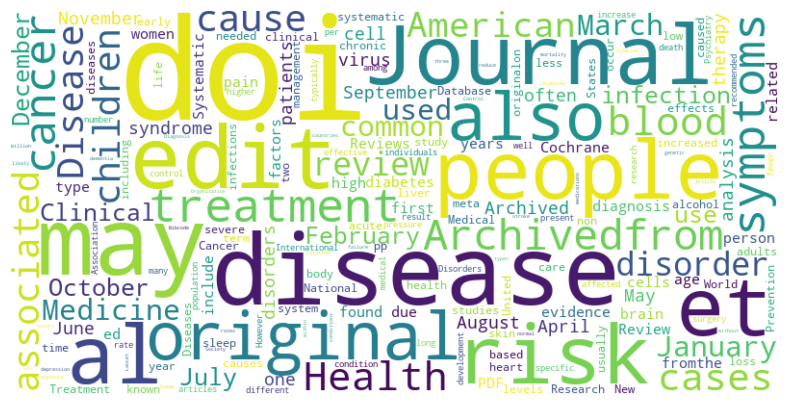

In [15]:
# Generating wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(filtered_counts)

# Output
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()